# 02 Exploratory Analysis

This notebook calculates core business KPIs, identifies top categories and products, analyzes monthly trends, reviews regional performance, and measures the relationship between discounting and profit.

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import (
    business_summary,
    discount_profit_analysis,
    monthly_performance,
    sales_by_category,
    sales_by_region,
    top_products_by_sales,
)
from utils import save_plot

plt.style.use("ggplot")

## Load Cleaned Data

In [2]:
df = pd.read_csv(PROJECT_ROOT / "data" / "cleaned" / "ecommerce_data_cleaned.csv", parse_dates=["Order Date"])
print(f"Clean dataset shape: {df.shape}")
df.head()

Clean dataset shape: (1500, 14)


,Order ID,Order Date,Customer ID,Product Name,Category,Sales,Quantity,Discount,Profit,Region,Year,Month,Month Name,Profit Margin
0,ORD-20230001,2023-01-31,CUST-1047,Air Fryer,Home & Kitchen,85.42,1,0.00,22.89,West,2023,1,January,0.267970
1,ORD-20230002,2023-01-07,CUST-1388,Wireless Mouse,Electronics,99.86,3,0.15,14.98,East,2023,1,January,0.150010
2,ORD-20230003,2023-02-14,CUST-1373,Lipstick Pack,Beauty,11.69,1,0.25,-3.64,South,2023,2,February,-0.311377
3,ORD-20230004,2023-07-16,CUST-1360,Denim Jacket,Fashion,79.09,1,0.10,20.73,Central,2023,7,July,0.262106
4,ORD-20230005,2024-01-15,CUST-1181,Bluetooth Speaker,Electronics,660.96,6,0.20,82.60,West,2024,1,January,0.124970


## KPI Summary

In [3]:
summary = business_summary(df)
total_revenue = summary["total_sales"]
total_profit = summary["total_profit"]
average_order_value = summary["average_order_value"]
profit_margin = summary["profit_margin"] * 100

kpi_df = pd.DataFrame(
    {
        "Metric": ["Total Revenue", "Total Profit", "Average Order Value", "Profit Margin (%)"],
        "Value": [total_revenue, total_profit, average_order_value, profit_margin],
    }
)
kpi_df

,Metric,Value
0,Total Revenue,226161.710000
1,Total Profit,46756.390000
2,Average Order Value,150.774473
3,Profit Margin (%),20.673875


## Top Categories

In [4]:
category_summary = sales_by_category(df)
category_summary["profit_margin_pct"] = np.where(
    category_summary["sales"] > 0,
    (category_summary["profit"] / category_summary["sales"]) * 100,
    0,
)
category_summary

,Category,sales,profit,quantity,profit_margin_pct
1,Electronics,105428.62,17299.27,966,16.408514
3,Home & Kitchen,53105.21,10871.48,739,20.471588
2,Fashion,27405.68,7941.48,672,28.977497
4,Sports,25056.25,5906.55,512,23.573160
0,Beauty,15165.95,4737.61,438,31.238465


In [5]:
top_categories = category_summary.head(5)
top_categories

,Category,sales,profit,quantity,profit_margin_pct
1,Electronics,105428.62,17299.27,966,16.408514
3,Home & Kitchen,53105.21,10871.48,739,20.471588
2,Fashion,27405.68,7941.48,672,28.977497
4,Sports,25056.25,5906.55,512,23.573160
0,Beauty,15165.95,4737.61,438,31.238465


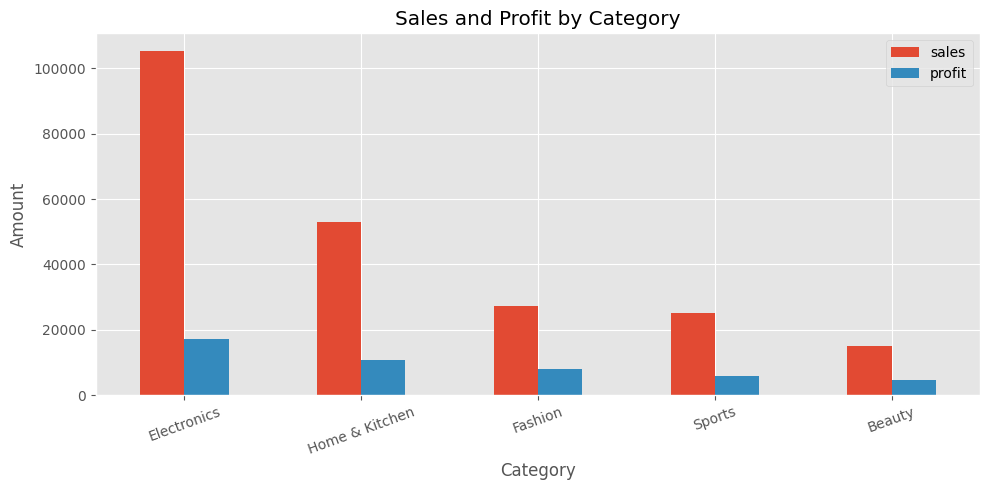

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
category_summary.plot(kind="bar", x="Category", y=["sales", "profit"], ax=ax)
ax.set_title("Sales and Profit by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Amount")
plt.xticks(rotation=20)
plt.tight_layout()
save_plot(fig, "sales_profit_by_category.png")
plt.show()

## Top Products

In [7]:
top_products = top_products_by_sales(df, top_n=10)
top_products

,Product Name,sales,profit
23,Portable SSD,20806.27,3281.11
21,Noise Cancelling Headphones,20702.33,3100.15
27,Smart Watch,19738.67,3766.09
35,Vacuum Cleaner,15741.82,3416.53
20,Mechanical Keyboard,14641.30,2512.18
9,Dining Chair,11003.55,2244.05
2,Bluetooth Speaker,10656.18,1732.80
5,Cookware Set,9348.40,1918.24
37,Webcam,7978.38,1169.91
34,USB-C Hub,6696.80,1111.59


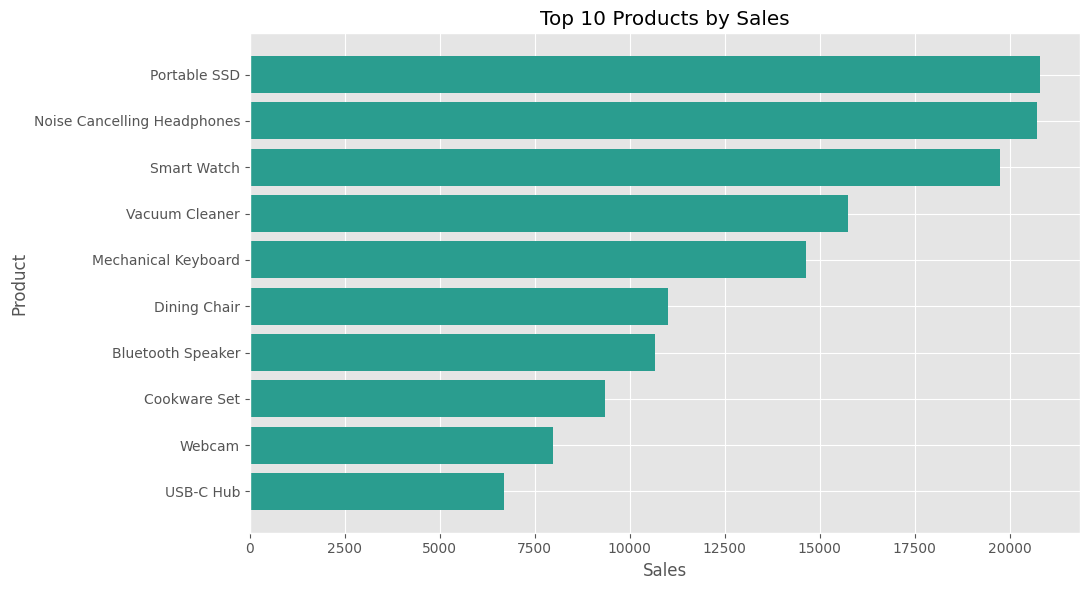

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products["Product Name"], top_products["sales"], color="#2a9d8f")
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales")
ax.set_ylabel("Product")
ax.invert_yaxis()
plt.tight_layout()
save_plot(fig, "top_products_by_sales.png")
plt.show()

## Monthly Sales and Profit Trends

In [9]:
monthly_summary = monthly_performance(df)
monthly_summary

,Month_Start,sales,profit,orders
0,2023-01-01,7667.08,1495.21,55
1,2023-02-01,4948.37,1032.04,49
2,2023-03-01,6495.83,1310.77,46
3,2023-04-01,7824.79,1610.79,62
4,2023-05-01,8823.16,2005.44,68
5,2023-06-01,8774.32,1912.55,57
6,2023-07-01,10028.85,1939.47,62
7,2023-08-01,9047.28,1793.30,63
8,2023-09-01,12162.15,2290.23,70
9,2023-10-01,9571.82,2361.54,72


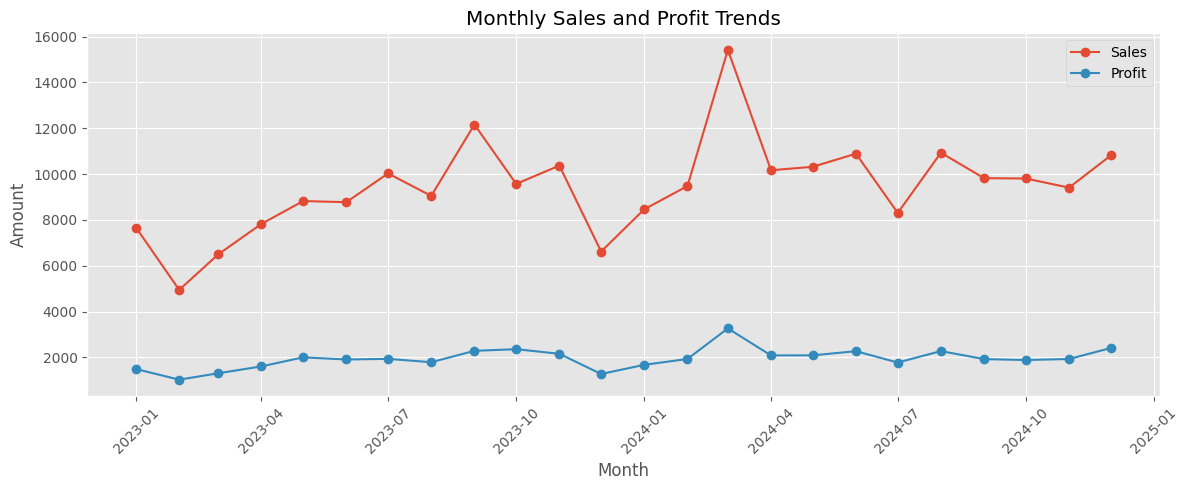

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_summary["Month_Start"], monthly_summary["sales"], marker="o", label="Sales")
ax.plot(monthly_summary["Month_Start"], monthly_summary["profit"], marker="o", label="Profit")
ax.set_title("Monthly Sales and Profit Trends")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(fig, "monthly_sales_profit_trends.png")
plt.show()

## Regional Performance

In [11]:
region_summary = sales_by_region(df)
region_summary["profit_margin_pct"] = np.where(
    region_summary["sales"] > 0,
    (region_summary["profit"] / region_summary["sales"]) * 100,
    0,
)
region_summary

,Region,sales,profit,orders,profit_margin_pct
2,North,58604.21,11982.83,357,20.447046
4,West,49769.27,10605.70,320,21.309736
3,South,46825.68,9261.15,303,19.777930
1,East,41052.22,8189.66,281,19.949372
0,Central,29910.33,6717.05,239,22.457292


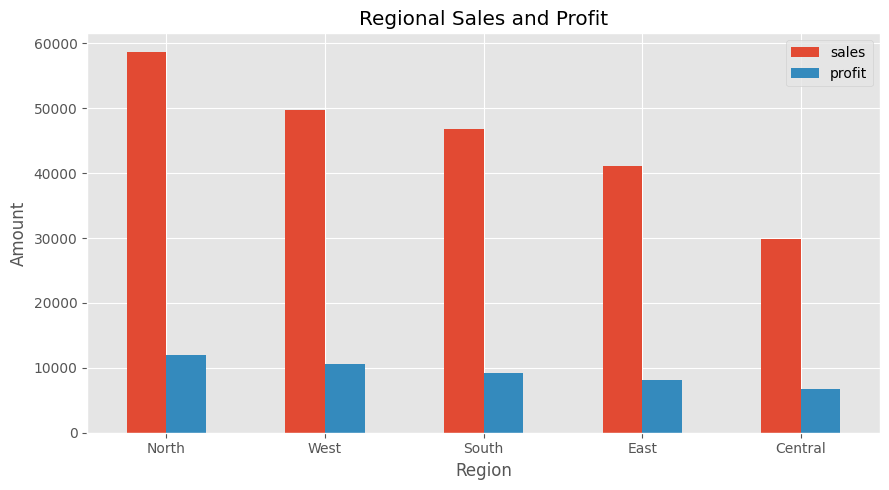

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
region_summary.plot(kind="bar", x="Region", y=["sales", "profit"], ax=ax)
ax.set_title("Regional Sales and Profit")
ax.set_xlabel("Region")
ax.set_ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
save_plot(fig, "regional_sales_profit.png")
plt.show()

## Impact of Discount on Profit

In [13]:
discount_summary = discount_profit_analysis(df)
discount_summary

,Discount Band,sales,profit,average_profit
0,0%,61682.76,16662.54,50.037658
1,1-10%,86158.49,19156.20,35.278453
2,11-20%,54898.84,9230.48,21.516270
3,21-30%,23421.62,1707.17,8.754718
4,30%+,0.00,0.00,NaN


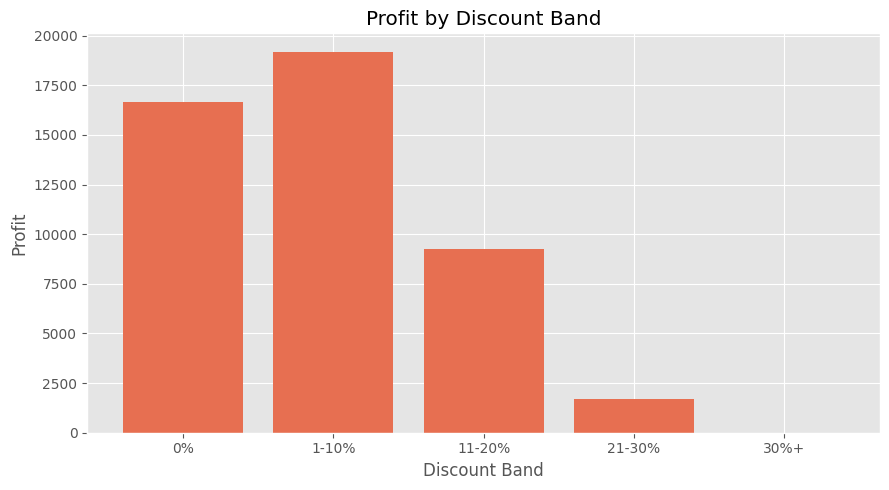

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(discount_summary["Discount Band"].astype(str), discount_summary["profit"], color="#e76f51")
ax.set_title("Profit by Discount Band")
ax.set_xlabel("Discount Band")
ax.set_ylabel("Profit")
plt.tight_layout()
save_plot(fig, "profit_by_discount_band.png")
plt.show()

The main findings from this notebook will be translated into business actions in the final notebook.